In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
import torch.optim as optim

In [2]:
transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, ), (0.5, ))
])

In [3]:
train_data = datasets.MNIST(root = "./data", train = True, download = True, transform=transforms)
test_data = datasets.MNIST(root = "./data", train = False, download = True, transform=transforms)

100%|██████████| 9.91M/9.91M [00:00<00:00, 53.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.65MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.2MB/s]


In [33]:
from torch.utils.data import DataLoader
train_loader = DataLoader(train_data, batch_size = 64, shuffle = True)
test_loader = DataLoader(test_data, batch_size = 16, shuffle = False)

In [5]:
images, labels = next(iter(train_loader))

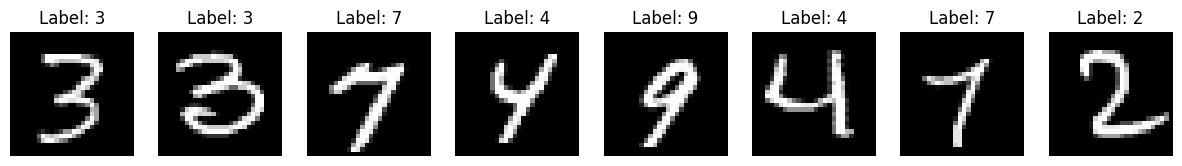

In [6]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 8, figsize = (15, 2))
for i, ax in enumerate(axes):
  ax.imshow(images[i].squeeze(), cmap = "gray")
  ax.set_title(f"Label: {labels[i].item()}")
  ax.axis('off')
plt.show()

In [7]:
class TeacherMLP(nn.Module):
  def __init__(self, hidden1 = 512, hidden2 = 256):
    super().__init__()
    self.net = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28*28, hidden1),
        nn.ReLU(),
        nn.Linear(hidden1, hidden2),
        nn.ReLU(),
        nn.Linear(hidden2, 10)
    )
  def forward(self, x):
    return self.net(x)

In [8]:
teacher = TeacherMLP(hidden1 = 512, hidden2 = 256)

In [9]:
teacher

TeacherMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [10]:
## Train Teacher
def train_teacher(model, loader, epochs = 3, lr = 1e-3):
  opt = optim.Adam(model.parameters(), lr=lr)
  loss_fn = nn.CrossEntropyLoss()
  model.train()
  for ep in range(epochs):
    total_loss = 0
    for x, y in loader:
      opt.zero_grad()

      out = model(x)
      loss = loss_fn(out, y)
      loss.backward()
      opt.step()
      total_loss += loss.item()
    print(f"Teacher Epoch {ep + 1}: Loss: {total_loss / len(loader):.4f}")

In [11]:
train_teacher(teacher, train_loader)

Teacher Epoch 1: Loss: 0.3037
Teacher Epoch 2: Loss: 0.1364
Teacher Epoch 3: Loss: 0.1032


In [12]:
print(teacher.state_dict())

OrderedDict({'net.1.weight': tensor([[-0.0031,  0.0191,  0.0023,  ...,  0.0253, -0.0038, -0.0280],
        [ 0.0338,  0.0024,  0.0222,  ...,  0.0104,  0.0329, -0.0038],
        [ 0.0235,  0.0225, -0.0128,  ..., -0.0101, -0.0080, -0.0276],
        ...,
        [-0.0229, -0.0317, -0.0003,  ..., -0.0198,  0.0055,  0.0252],
        [-0.0087,  0.0064,  0.0334,  ...,  0.0378, -0.0210,  0.0031],
        [-0.0166, -0.0003,  0.0008,  ...,  0.0039, -0.0129,  0.0385]]), 'net.1.bias': tensor([ 4.4184e-03, -2.7726e-02, -2.0104e-02, -1.9723e-02, -9.2211e-03,
         1.7058e-02, -2.5765e-03, -7.4377e-03, -5.8616e-03, -2.7874e-02,
         8.8877e-03,  6.0776e-03, -2.6024e-02,  5.6579e-03,  2.0289e-03,
         1.6609e-02, -1.6949e-02,  2.6892e-02,  5.2531e-03, -3.5645e-02,
         1.3529e-02,  1.9924e-02, -2.1494e-02,  6.1669e-03, -3.5511e-02,
         1.3744e-02,  1.8140e-02, -1.8597e-02, -1.1190e-02, -1.0030e-02,
         2.0028e-02, -2.8697e-02,  1.7091e-02,  2.8056e-02, -3.7296e-02,
         8.

In [19]:
# Student Model (1 Hidden Layer)
class StudentModel(nn.Module):
  def __init__(self, hidden = 128):
    super().__init__()
    self.net = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, hidden),
        nn.ReLU(),
        nn.Linear(hidden, 10)
    )

  def forward(self, x):
    return self.net(x)

In [20]:
student = StudentModel(hidden = 128)

In [21]:
print(student)

StudentModel(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


### **Distilation Training**

In [22]:
temperature = 2.0
alpha = 0.7
ce_loss = nn.CrossEntropyLoss()
kl_loss = nn.KLDivLoss(reduction = 'batchmean')
optimizer = optim.Adam(student.parameters(), lr = 1e-3)

In [23]:
def distillation(student, teacher, loader, epochs = 3):
  """
  Performs Distillation from teacher model to student model
  Args:
    student: Untrained student model
    teacher: Pretrained Teacher model already learned
    loader: DataLoader
  """
  for ep in range(epochs):
    student.train()
    total_loss = 0
    for x, y in loader:
      # Teacher Outputs
      with torch.no_grad():
        t_logits = teacher(x)
        t_probs = torch.softmax(t_logits / temperature, dim = 1)

      # Student Outputs
      s_logits = student(x)
      s_log_probs = torch.log_softmax(s_logits / temperature, dim = 1)

      # Losses
      loss_soft = kl_loss(s_log_probs, t_probs) * (temperature ** 2)
      loss_hard = ce_loss(s_logits, y) # Student logits and labels
      # Final Distillized Loss
      loss = alpha * loss_soft + (1 - alpha) * loss_hard

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      total_loss += loss.item()
    print(f"Student Epoch: {ep + 1} | Loss: {total_loss / len(loader):.4f}")

In [24]:
distillation(student, teacher, train_loader)

Student Epoch: 1 | Loss: 0.7805
Student Epoch: 2 | Loss: 0.2450
Student Epoch: 3 | Loss: 0.1366


In [25]:
# Evaluate
def evaluate(model, loader, name = "Model"):
  model.eval()
  correct, total = 0, 0
  with torch.no_grad():
    for x, y in loader:
      out = model(x)
      preds = out.argmax(dim = 1)
      correct += (preds == y).sum().item()
      total += y.size(0)
  acc = correct / total * 100
  print(f"{name} | Accuracy: {acc:.2f}%")
  return acc

### **Evaluating both the model**

#### **`Teacher Evaluation`**

In [26]:
evaluate(teacher, train_loader, name = "Teacher")

Teacher | Accuracy: 97.17%


97.16833333333334

#### **`Student Evaluation`**

In [27]:
evaluate(student, train_loader, name = "Student")

Student | Accuracy: 96.73%


96.73333333333333

### **Predictions**

In [34]:
def predict(model, x):
  model.eval()
  with torch.no_grad():
    out = model(x)
    return out.argmax(dim = 1)

In [35]:
sample_batch, sample_labels = next(iter(test_loader))

#### **`Teacher Model Predictions`**

In [41]:
teacher_preds = predict(teacher, sample_batch)

In [42]:
teacher_preds

tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5])

### **`Student Model Predictions`**

In [43]:
student_preds = predict(student, sample_batch)

In [44]:
student_preds

tensor([7, 2, 1, 0, 4, 1, 4, 9, 6, 9, 0, 6, 9, 0, 1, 5])

##### **`Comparing both preds`**

In [46]:
teacher_preds == student_preds

tensor([ True,  True,  True,  True,  True,  True,  True,  True, False,  True,
         True,  True,  True,  True,  True,  True])

In [47]:
# Save the model
torch.save(student.state_dict(), "Student_distilled_model.pth")